In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
print(sys.executable)

df = pd.read_csv(
    "../data/raw/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv",
    low_memory=False
)


print(df.shape)
df.head()

It looks like there are many different mutations types including insertions. We want to subset the dataset down to just amino acid swaps. 

In [3]:
df["mut_type"].value_counts(dropna=False)
#df["ddG_ML"].isna().value_counts()
#df["dG_ML"].isna().value_counts()


## We want to substitute down to only 
single_mut_df = df[df["mut_type"].str.fullmatch(r"[A-Z]\d+[A-Z]", na=False)].copy()
#print(df.shape) #(776298, 37))
#print(single_mut_df.shape) #(487914, 37)

single_mut_df[["name", "WT_name", "mut_type", "aa_seq", "ddG_ML"]].head(20)

## need to convert ddG_ML to strings 
single_mut_df['ddG_ML'] = pd.to_numeric(single_mut_df["ddG_ML"],errors="coerce")

single_mut_df['ddG_ML'].isna().sum() ## 98846
## Drop all ddG_ML that were NAs
single_mut_df = single_mut_df.dropna(subset=["ddG_ML"]).copy()
single_mut_df.shape #(389068, 37)

(389068, 37)

Single mutants: 389068
WT proteins: 412
WT clusters: 130


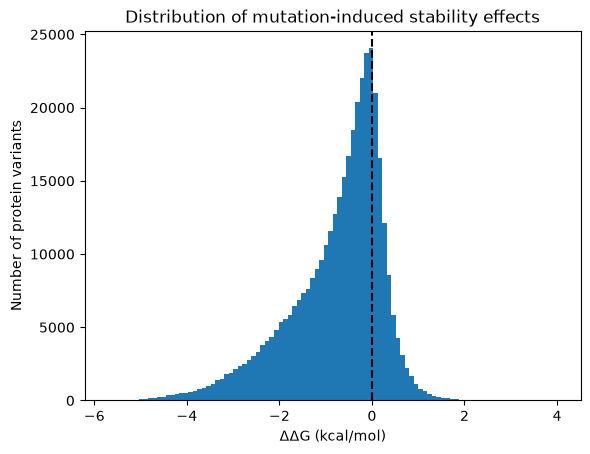

Fraction Stabilizing: 0.22184039807951308
Fraction Strongly Stabilizing: 0.008389278994931477


In [4]:
## Explore the data
print("Single mutants:", len(single_mut_df))
print("WT proteins:", single_mut_df["WT_name"].nunique())
print("WT clusters:", single_mut_df["WT_cluster"].nunique())

plt.hist(single_mut_df['ddG_ML'], bins = 100)
plt.axvline(0, linestyle="--", color = 'black')
plt.ylabel('Number of protein variants')
plt.xlabel("ΔΔG (kcal/mol)")
plt.title("Distribution of mutation-induced stability effects")
plt.show()

print('Fraction Stabilizing:', (single_mut_df['ddG_ML'] > 0).mean())
print('Fraction Strongly Stabilizing:', (single_mut_df['ddG_ML'] > 1).mean())

This makes sense as most mutations are destabilizing. Only a small fraction are stabilizing > 0 (22%)

In [ ]:
single_mut_df.head()

proteins_per_cluster = (
    single_mut_df[
        ["WT_name", "WT_cluster"]
    ]
    .drop_duplicates()
    .groupby("WT_cluster")
    .size()
)

proteins_per_cluster.describe()
single_mut_df[["WT_name", "WT_cluster"]]
single_mut_df[["WT_cluster"]].value_counts()


We still need to extract some additional data about where amino acid is lcoated

In [ ]:
## Ok lets get single_mut_df ready for processing
single_mut_df[["mut_type", "aa_seq", "ddG_ML"]]
X_df = single_mut_df[["WT_name", "mut_type", "aa_seq"]].copy()

from src.features import parse_mutations
X_df = parse_mutations(X_df)

y_df = single_mut_df["ddG_ML"].copy()

print(X_df.shape)
print(y_df.shape)
X_df

X_df.to_pickle('../data/processed/X_df.pkl')
y_df.to_pickle('../data/processed/y_df.pkl')

Moving onto notebook 2 we will split the data and begin building the model.